In [14]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from shapely.geometry import LineString


In [26]:
h0byr0 = 0.026
r0 = 0.018
rt = 0.07
h0 = h0byr0*r0
mu = 56.10e3
N = 16.33
r = np.linspace(r0,rt,100)
lam = r/r0
v = lam**3

In [ ]:
P = h0byr0*(2*mu*( lam**(-1) - lam**(-7))*(2*lam**2 + lam**-4 - 9*N))/(3*(2*lam**2 + lam**-4 - 3*N))
P= P/1000

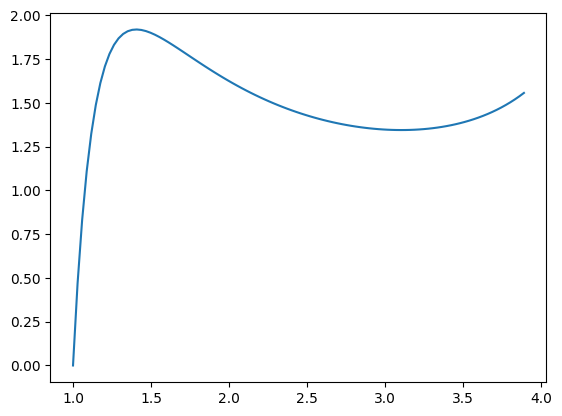

In [13]:
plt.plot(lam, P)

In [38]:
def plotPlam_f_intersections(lam,P):
    lamf = np.flip(lam)
    plt.plot(lam, P)
    plt.plot(lamf, P)
    first_line = LineString(np.column_stack((lam, P)))
    second_line = LineString(np.column_stack((lamf, P)))
    intersection = first_line.intersection(second_line)

    if intersection.geom_type == 'MultiPoint':
        x, y = LineString(intersection.geoms).xy
        plt.plot(x,y,'o')
    # elif intersection.geom_type == 'Point':
    #     plt.plot(*intersection.xy, 'o')



In [40]:
frPup = P + 0.5
frPdwn = P - 0.5

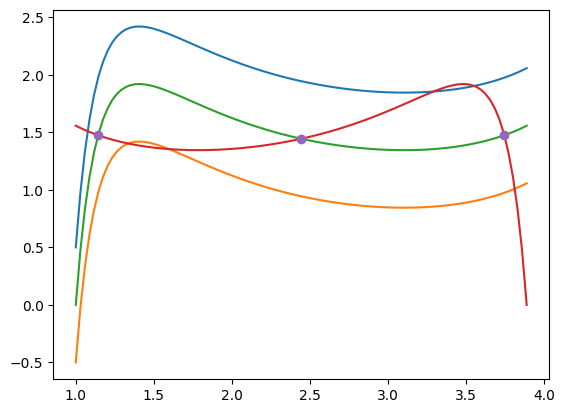

In [41]:
plt.plot(lam, frPup)
plt.plot(lam, frPdwn)
plotPlam_f_intersections(lam, P)

In [46]:
import pandas as pd
import re

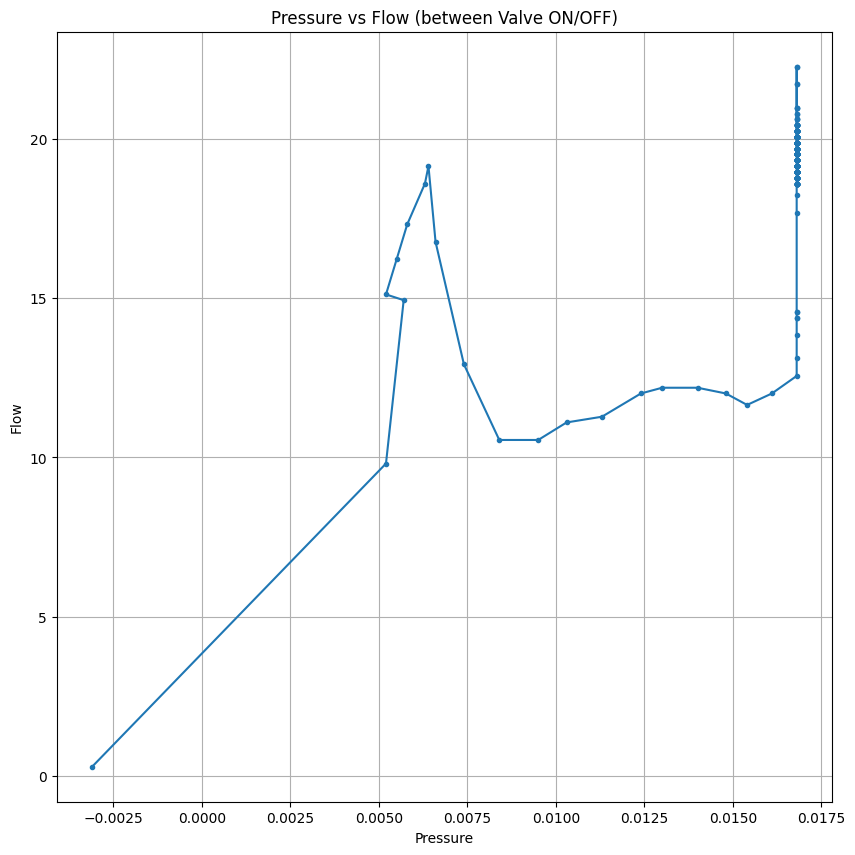

In [53]:
# filepath = "D:\ucla_research\Projects\experiment_setup\Sensor Logs\PV1.txt"
filepath = "D:/ucla_research/Projects/experiment_setup/Sensor Logs/PV1.txt"

# regex patterns
data_pattern = re.compile(r'^\[(.*?)\]\s+([-0-9.eE]+),([-0-9.eE]+)')
valve_on_pattern = re.compile(r'^\[(.*?)\]\s+Valve ON')
valve_off_pattern = re.compile(r'^\[(.*?)\]\s+Valve OFF')

records = []
keep = False   # flag to track whether we are between Valve ON and OFF

with open(filepath, "r") as f:
    for line in f:
        line = line.strip()

        if valve_on_pattern.match(line):
            keep = True
            continue
        elif valve_off_pattern.match(line):
            keep = False
            continue

        if keep:
            m = data_pattern.match(line)
            if m:
                timestamp = pd.to_datetime(m.group(1))
                pressure = float(m.group(2))
                flow = float(m.group(3))
                records.append((timestamp, pressure, flow))

# create DataFrame
df = pd.DataFrame(records, columns=["time", "pressure", "flow"])

# plot pressure vs flow
plt.figure(figsize=(10,10))
plt.plot(df["pressure"], df["flow"], 'o-', markersize=3)
plt.xlabel("Pressure")
plt.ylabel("Flow")
plt.title("Pressure vs Flow (between Valve ON/OFF)")
plt.grid(True)
plt.show()

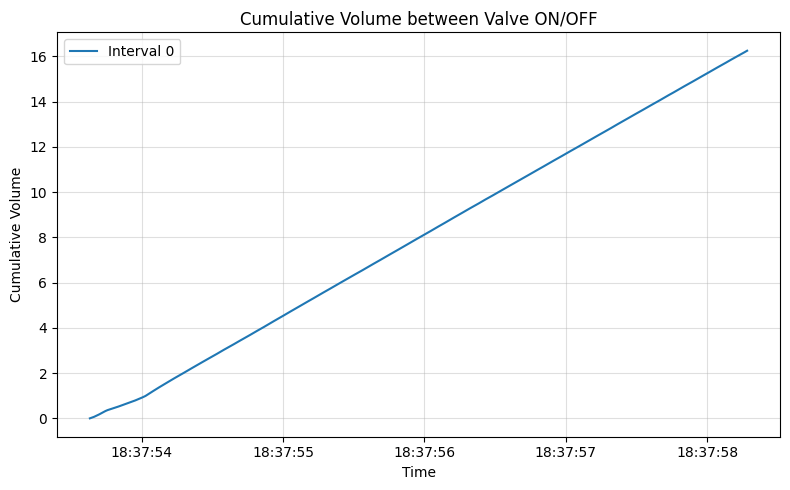

In [55]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import re
from pathlib import Path

# --- CONFIG ---
filepath = r"D:/ucla_research/Projects/experiment_setup/Sensor Logs/PV1.txt"  # use / or a raw string
# If your flow is not in per-second units, scale it here.
# For example, if flow is in L/min, set FLOW_RATE_SCALE = 1/60 to convert to L/s before integrating.
FLOW_RATE_SCALE = 11/60

# --- Patterns ---
data_pat = re.compile(r'^\[(.*?)\]\s+([-0-9.eE]+),([-0-9.eE]+)')  # [timestamp] pressure,flow
on_pat   = re.compile(r'^\[(.*?)\]\s+Valve ON')
off_pat  = re.compile(r'^\[(.*?)\]\s+Valve OFF')

rows = []
keep = False
seg = -1  # segment id (increments at each Valve ON)

with open(Path(filepath), 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        if on_pat.match(line):
            keep = True
            seg += 1
            continue

        if off_pat.match(line):
            keep = False
            continue

        if keep:
            m = data_pat.match(line)
            if m:
                ts = pd.to_datetime(m.group(1))
                pressure = float(m.group(2))
                flow = float(m.group(3)) * FLOW_RATE_SCALE  # ensure flow is per-second units
                rows.append((seg, ts, pressure, flow))

# Build DataFrame
df = pd.DataFrame(rows, columns=['segment', 'time', 'pressure', 'flow'])

if df.empty:
    raise SystemExit("No data found between Valve ON and Valve OFF with the expected numeric format.")

# Sort and compute per-segment time deltas
df = df.sort_values(['segment', 'time'])
df['dt'] = df.groupby('segment')['time'].diff().dt.total_seconds().fillna(0)

# Trapezoidal integration per segment:
# increment_i = (flow_i + flow_{i-1})/2 * dt_i
df['flow_prev'] = df.groupby('segment')['flow'].shift(1)
df['inc'] = ((df['flow'] + df['flow_prev']) / 2.0) * df['dt']
df['volume'] = df.groupby('segment')['inc'].cumsum().fillna(0.0)

# --- Plot: Volume vs Time, one curve per ON/OFF interval ---
plt.figure(figsize=(8,5))
for seg_id, g in df.groupby('segment'):
    if len(g) < 2:
        continue  # need at least two points to integrate meaningfully
    plt.plot(g['time'], g['volume'], label=f'Interval {seg_id}')

plt.xlabel('Time')
plt.ylabel('Cumulative Volume')
plt.title('Cumulative Volume between Valve ON/OFF')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [62]:
df1 = df.drop("segment", axis=1)

In [68]:
df1.head()

,time,pressure,flow,dt,flow_prev,inc,volume
0,2025-09-10 18:37:53.634,-0.0031,0.053167,0.000,NaN,NaN,0.000000
1,2025-09-10 18:37:53.634,0.0052,1.798500,0.000,0.053167,0.000000,0.000000
2,2025-09-10 18:37:53.664,0.0057,2.739000,0.030,1.798500,0.068062,0.068062
3,2025-09-10 18:37:53.664,0.0052,2.772000,0.000,2.739000,0.000000,0.068062
4,2025-09-10 18:37:53.680,0.0055,2.973667,0.016,2.772000,0.045965,0.114028


C:\Users\Anwesha\AppData\Local\Temp\ipykernel_14328\3188785661.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


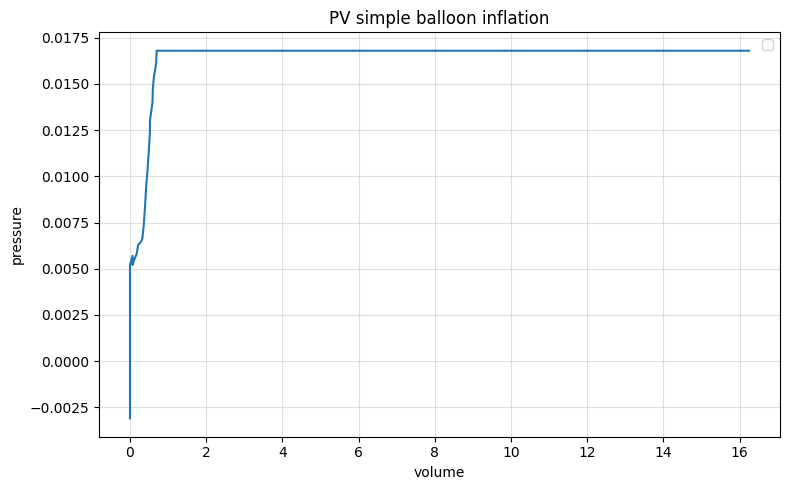

In [65]:
plt.figure(figsize=(8,5))

plt.plot(df['volume'], df['pressure'])

plt.xlabel('volume')
plt.ylabel('pressure')
plt.title('PV simple balloon inflation')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from scipy.signal import medfilt, butter, filtfilt


# --- CONFIG ---
# filepath = r"D:/ucla_research/Projects/experiment_setup/Sensor Logs/PV_fresh_balloon_1.txt"
# filepath = r"D:/ucla_research/Projects/experiment_setup/Sensor Logs/PV_0xB_3.txt"
# filepath = r"D:/ucla_research/Projects/experiment_setup/Sensor Logs/PV_Open_2.txt"
# filepath = r"D:/ucla_research/Projects/experiment_setup/Sensor Logs/PV_0xBVulc_1.txt"
filepath = r"D:/ucla_research/Projects/experiment_setup/Sensor Logs/PV_0xBR_volumeTest_1.txt"

def readPQ_sensorData(filepath):
    # --- Patterns ---
    data_pat = re.compile(r'^\[(.*?)\]\s+([-0-9.eE]+),([-0-9.eE]+)')
    on_pat   = re.compile(r'^\[(.*?)\]\s+Valve ON')
    off_pat  = re.compile(r'^\[(.*?)\]\s+Valve OFF')

    rows = []
    keep = False

    with open(Path(filepath), 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if not keep:
                if on_pat.match(line):
                    keep = True
                continue
            else:
                if off_pat.match(line):
                    break
                m = data_pat.match(line)
                if m:
                    ts = pd.to_datetime(m.group(1))
                    pressure_mV = float(m.group(2))
                    pressure_kPa = 1000*( pressure_mV + 0.003)
                    flow_Lmin = float(m.group(3))
                    flow_Ls = flow_Lmin / 60.0    # convert to L/s
                    rows.append((ts, pressure_kPa, flow_Ls))

    # Build DataFrame
    df = pd.DataFrame(rows, columns=['time', 'pressure', 'flow_Ls'])
    if df.empty:
        raise SystemExit("No numeric data found between 'Valve ON' and 'Valve OFF'.")
    df['t_rel'] = (df['time'] - df['time'].iloc[0]).dt.total_seconds()

    return df

def filter_flow(df, Fs):
    # --- Filtering params (tune these) ---
    Fs = 1000.0                 # sampling rate (Hz), since you treat samples as 1 ms apart
    dt = 1.0 / Fs               # 0.001 s
    median_win = 11             # must be odd; ~11 ms median to remove spikes
    cutoff_hz = 12.0            # low-pass cutoff frequency (try 8–20 Hz depending on your signal)
    butter_order = 3

    # --- Stage 1: median filter to remove spikes ---
    flow_med = medfilt(df['flow_Ls'].to_numpy(), kernel_size=median_win)

    # --- Stage 2: zero-phase Butterworth low-pass (no phase lag) ---
    b, a = butter(butter_order, Wn=cutoff_hz / (0.5 * Fs), btype='low')
    flow_clean = filtfilt(b, a, flow_med)

    # from scipy.signal import savgol_filter
    # flow_clean = savgol_filter(flow_med, window_length=31, polyorder=3)  # ~31 ms windo

    # --- Recompute cumulative volume from smoothed flow (L) ---
    volume_clean = np.cumsum(flow_clean * dt)

    # Store results
    df['flow_clean_Ls'] = flow_clean
    df['volume_clean']  = volume_clean
    return df

# # Integration with fixed dt = 1 ms
# dt = 0.001  # 1 ms timestep
# df['volume'] = (df['flow_Ls'] * dt).cumsum()


def plot_flowVtime_cleaned(df):
    plt.figure(figsize=(9,4))
    plt.plot(df['t_rel'], df['flow_Ls'],  label='Flow (raw)', alpha=0.5)
    plt.plot(df['t_rel'], df['flow_clean_Ls'], label='Flow (clean)', linewidth=2)
    plt.xlabel('Time [s]')
    plt.ylabel('Flow [L/s]')
    plt.title('Flow vs Time (Median + Zero-Phase Low-Pass)')
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()




In [ ]:


def get_volume_percent(df: pd.DataFrame, p_start: float, p_end: float,
                       time_col: str = 't_rel', flow_col: str = 'flow_Ls') -> float:
    """
    Integrate total volume [L] between two percentages of the recording duration.

    Parameters
    ----------
    df : DataFrame
        Must contain:
          - time_col: relative time in seconds (starts at 0)
          - flow_col: flow in L/s (not L/min!)
    p_start, p_end : float
        Percentages in [0, 100]. Example: 0, 50 for start to halfway.
    time_col : str
        Name of the relative time column (default 't_rel').
    flow_col : str
        Name of the flow column in L/s (default 'flow_Ls').

    Returns
    -------
    float
        Volume in liters over the requested percentage window.
    """
    if df.empty:
        return 0.0

    # Ensure sorted and extract arrays
    g = df.sort_values(time_col)
    t = g[time_col].to_numpy(dtype=float)
    q = g[flow_col].to_numpy(dtype=float)

    # Clamp and order percentages
    p0 = float(np.clip(p_start, 0.0, 100.0))
    p1 = float(np.clip(p_end,   0.0, 100.0))
    if p1 < p0:
        p0, p1 = p1, p0

    t0_all, t1_all = t[0], t[-1]
    T = t1_all - t0_all
    if T <= 0:
        return 0.0

    # Map percentages to absolute times
    t0 = t0_all + T * (p0 / 100.0)
    t1 = t0_all + T * (p1 / 100.0)
    if t1 <= t0:
        return 0.0

    # Build segment arrays within [t0, t1], inserting endpoints via interpolation
    mask = (t >= t0) & (t <= t1)
    t_seg = t[mask]
    q_seg = q[mask]

    # Insert start endpoint if needed
    if t_seg.size == 0 or t_seg[0] > t0:
        t_seg = np.insert(t_seg, 0, t0)
        q_seg = np.insert(q_seg, 0, np.interp(t0, t, q))
    # Insert end endpoint if needed
    if t_seg[-1] < t1:
        t_seg = np.append(t_seg, t1)
        q_seg = np.append(q_seg, np.interp(t1, t, q))

    # Ensure sorted (in case t0/t1 landed before/after interior points)
    order = np.argsort(t_seg)
    t_seg = t_seg[order]
    q_seg = q_seg[order]

    # Trapezoidal integration: ∫ q(t) dt over [t0, t1]
    volume_L = np.trapezoid(q_seg, t_seg)  # q is L/s, t is s → liters
    volume_mL = volume_L * 1000.0
    return float(volume_mL)


In [168]:
df = readPQ_sensorData(filepath)

In [170]:
v_tot = get_volume_percent(df,0,100)
print(f"Total volume between button presses: {v_tot:.2f} mL")

Total volume between button presses: 5109.27 mL


In [173]:
df_fc = filter_flow(df)
plot_flowVtime_cleaned(df_fc)
v_tot_fc = get_volume_percent(df_fc,0,100, time_col="t_rel",flow_col="flow_clean_Ls")
print(f"Total volume between button presses: {v_tot_fc:.2f} mL")

TypeError: filter_flow() missing 1 required positional argument: 'Fs'

In [171]:

def plot_peakSS_flow():
    # Choose the flow column: prefer cleaned, else raw (converted to L/s)
    flow_col = 'flow_clean_Ls' if 'flow_clean_Ls' in df.columns else 'flow_Ls'

    # --- Stabilization detection params (same style as earlier) ---
    window_ms     = 200     # rolling std window (samples; ~ms)
    stable_dur_ms = 500     # need at least this many consecutive stable samples
    rel_thresh    = 0.02    # relative threshold wrt robust range
    abs_thresh    = 0.002   # absolute floor (units of your pressure; adjust if needed)

    # Robust pressure range to set threshold
    p_lo, p_hi = df['pressure'].quantile([0.01, 0.99])
    p_range = max(p_hi - p_lo, 1e-12)
    thresh = max(rel_thresh * p_range, abs_thresh)

    # Rolling std of pressure to detect steady state
    roll_std = df['pressure'].rolling(window_ms, center=True, min_periods=window_ms).std()
    stable = (roll_std < thresh)
    run = stable.rolling(stable_dur_ms, min_periods=stable_dur_ms).sum()

    # Find first stable run; steady-state = median flow over that run
    steady_idx = None
    if run.max() == stable_dur_ms:
        first_stable_end = run.idxmax()               # label/index at the end of the first stable window
        end_pos = run.index.get_loc(first_stable_end) # integer position
        start_pos = max(end_pos - (stable_dur_ms - 1), 0)
        steady_idx = (start_pos, end_pos)
        steady_state_flow = df.iloc[start_pos:end_pos+1][flow_col].median()
        steady_state_time = df.iloc[start_pos:end_pos+1]['t_rel'].median()
    else:
        # Fallback: median over last 10% of samples
        k = max(int(0.1 * len(df)), 1)
        steady_state_flow = df[flow_col].tail(k).median()
        steady_state_time = df['t_rel'].tail(k).median()

    # Peak flow
    imax = int(df[flow_col].idxmax() if isinstance(df.index, pd.Index) else np.argmax(df[flow_col].to_numpy()))
    # If index is datetime, idxmax returns label; convert to position:
    try:
        imax = df.index.get_loc(df[flow_col].idxmax())
    except Exception:
        pass
    peak_flow = float(df.iloc[imax][flow_col])
    peak_time = float(df.iloc[imax]['t_rel'])


    # --- Plot: Flow vs Time with annotations ---
    plt.figure(figsize=(9,4))
    plt.plot(df['t_rel'], df[flow_col], label='Flow (clean)' if flow_col=='flow_clean_Ls' else 'Flow', linewidth=2)

    # Mark peak flow
    plt.scatter([peak_time], [peak_flow], s=50, color="red")
    plt.annotate(f'Peak: {peak_flow:.4g} L/s @ {peak_time:.3f}s',
                xy=(peak_time, peak_flow),
                xytext=(10, 10),
                textcoords='offset points',
                arrowprops=dict(arrowstyle="->"))

    # Mark steady-state flow (horizontal line across plot)
    plt.axhline(steady_state_flow, linestyle='--')
    plt.text(df['t_rel'].iloc[0], steady_state_flow,
            f'  Steady: {steady_state_flow:.4g} L/s',
            va='bottom')

    plt.xlabel('Time [s]')
    plt.ylabel('Flow [L/s]')
    plt.title('Flow vs Time with Peak and Steady-State Markers')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    # Optional: print details
    print(f"Peak flow: {peak_flow:.6g} L/s at t={peak_time:.3f} s")
    print(f"Steady-state flow: {steady_state_flow:.6g} L/s"
        + (f" (computed over [{steady_idx[0]}, {steady_idx[1]}])" if steady_idx else " (fallback: last 10% window)"))

    return


Text(0.5, 1.0, 'Pressure over time')

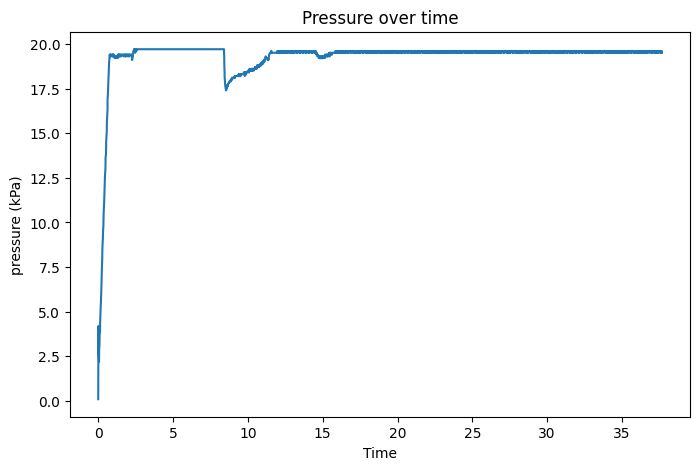

In [154]:
plt.figure(figsize=(8,5))
plt.plot(df['t_rel'], df['pressure'])
plt.xlabel('Time')
plt.ylabel('pressure (kPa)')
plt.title('Pressure over time')

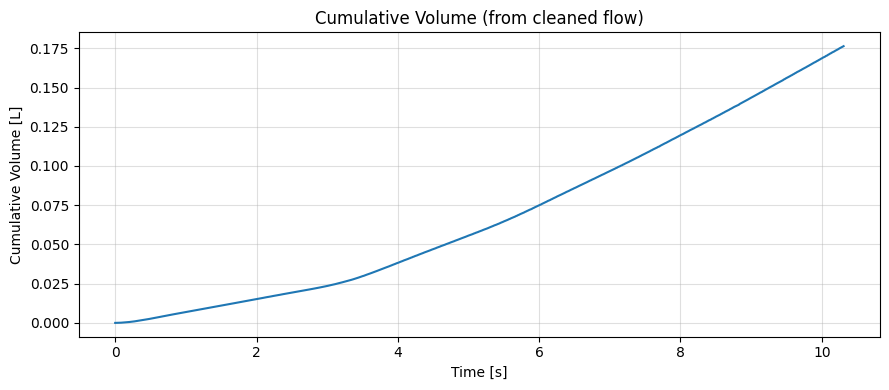

In [131]:
# 2) Volume vs time (from cleaned flow)
plt.figure(figsize=(9,4))
plt.plot(df['t_rel'], df['volume_clean'])
plt.xlabel('Time [s]')
plt.ylabel('Cumulative Volume [L]')
plt.title('Cumulative Volume (from cleaned flow)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

C:\Users\Anwesha\AppData\Local\Temp\ipykernel_14328\831356733.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


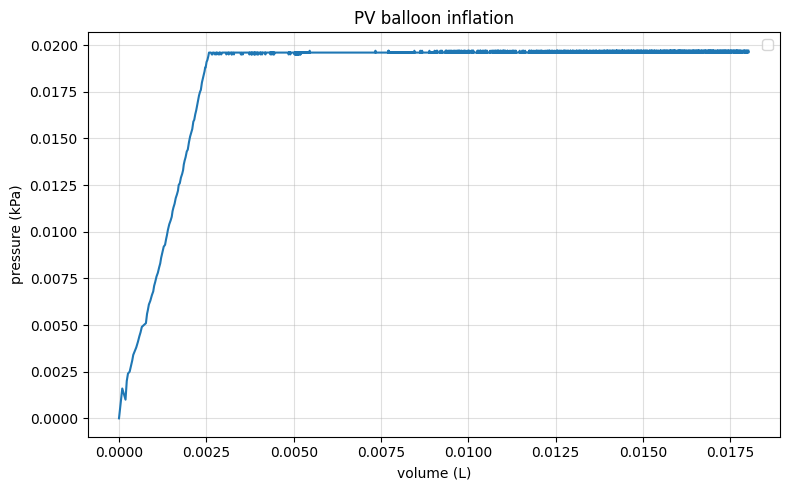

In [118]:
plt.figure(figsize=(8,5))

plt.plot(df['volume'], df['pressure'])

plt.xlabel('volume (L)')
plt.ylabel('pressure (kPa)')
plt.title('PV balloon inflation')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()